In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "Womens Clothing E-Commerce Reviews.csv"
)

# Dataset ki basic information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (23486, 11)

Column Names:
['number', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

First 5 Rows:


,number,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   number                   23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB


In [3]:
# Age column ki basic statistics
print("Age Column Statistics:")
display(df["Age"].describe())

# Missing values check
age_missing = df["Age"].isna().sum()

# Duplicate age values nahi, unique ages count karenge
age_unique = df["Age"].nunique()

# Invalid age values check
invalid_age_count = (
    (df["Age"] < 18) |
    (df["Age"] > 100)
).sum()

print("Missing Age Values:", age_missing)
print("Unique Age Values:", age_unique)
print("Minimum Age:", df["Age"].min())
print("Maximum Age:", df["Age"].max())
print("Invalid Age Values:", invalid_age_count)

Age Column Statistics:


count    23486.000000
mean        43.198544
std         12.279544
min         18.000000
25%         34.000000
50%         41.000000
75%         52.000000
max         99.000000
Name: Age, dtype: float64

Missing Age Values: 0
Unique Age Values: 77
Minimum Age: 18
Maximum Age: 99
Invalid Age Values: 0


In [4]:
# Original dataset ko preserve karne ke liye copy
df_clean = df.copy()

# Age ko numeric format mein convert karna
df_clean["Age"] = pd.to_numeric(
    df_clean["Age"],
    errors="coerce"
)

# Invalid ages ko missing mark karna
df_clean.loc[
    (df_clean["Age"] < 18) |
    (df_clean["Age"] > 100),
    "Age"
] = np.nan

# Cleaning ke baad missing values check
print(
    "Age missing after validation:",
    df_clean["Age"].isna().sum()
)

Age missing after validation: 0


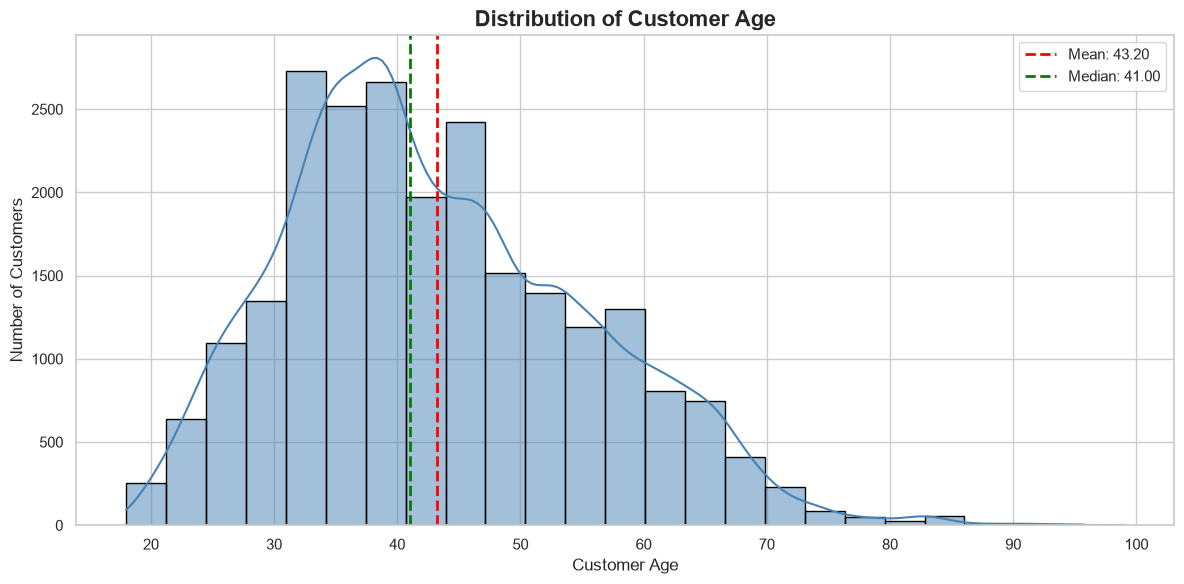

In [5]:
# Plot style
sns.set_theme(style="whitegrid")

# Figure create karna
plt.figure(figsize=(12, 6))

# Histogram with KDE curve
sns.histplot(
    data=df_clean,
    x="Age",
    bins=25,
    kde=True,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(
    df_clean["Age"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f'Mean: {df_clean["Age"].mean():.2f}'
)

plt.axvline(
    df_clean["Age"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f'Median: {df_clean["Age"].median():.2f}'
)

plt.title(
    "Distribution of Customer Age",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

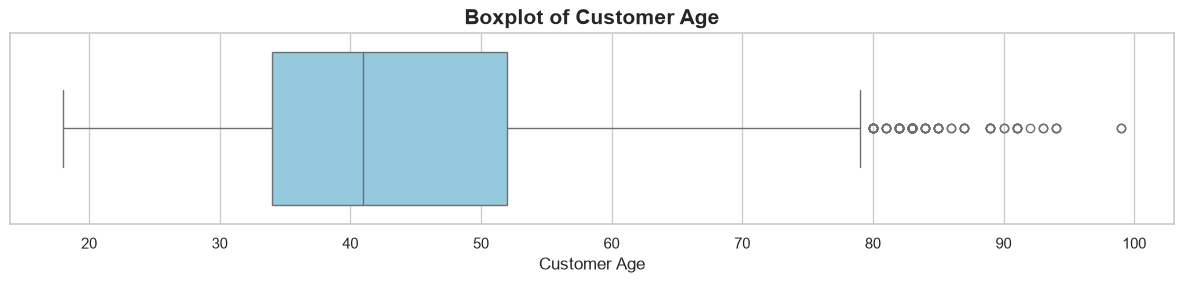

In [6]:
plt.figure(figsize=(12, 3))

sns.boxplot(
    data=df_clean,
    x="Age",
    color="skyblue"
)

plt.title(
    "Boxplot of Customer Age",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Customer Age")
plt.tight_layout()
plt.show()

In [7]:
# Quartiles calculate karna
Q1 = df_clean["Age"].quantile(0.25)
Q3 = df_clean["Age"].quantile(0.75)

# Interquartile Range
IQR = Q3 - Q1

# Outlier limits
lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

# Potential age outliers
age_outliers = df_clean[
    (df_clean["Age"] < lower_limit) |
    (df_clean["Age"] > upper_limit)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Potential Age Outliers:", len(age_outliers))

display(
    age_outliers["Age"]
    .value_counts()
    .sort_index()
    .to_frame("Customer Count")
)

Q1: 34.0
Q3: 52.0
IQR: 18.0
Lower Limit: 7.0
Upper Limit: 79.0
Potential Age Outliers: 109


,Customer Count
Age,
80.0,10
81.0,5
82.0,13
83.0,43
84.0,6
85.0,6
86.0,2
87.0,4
89.0,5


In [9]:
from sklearn.preprocessing import StandardScaler
# K-Means ke liye Age feature select karna
X_age = df_clean[["Age"]].copy()

print("Original Age Data:")
display(X_age.head())

print("Shape:", X_age.shape)
print("Missing Values:", X_age.isna().sum().sum())

Original Age Data:


,Age
0,33.0
1,34.0
2,60.0
3,50.0
4,47.0


Shape: (23486, 1)
Missing Values: 0


In [10]:
# StandardScaler object banana
age_scaler = StandardScaler()

# Age values ko standardize karna
X_age_scaled = age_scaler.fit_transform(X_age)

print("First 5 Original Ages:")
print(X_age.head().to_numpy().flatten())

print("\nFirst 5 Scaled Ages:")
print(X_age_scaled[:5].flatten())

print("\nScaled Mean:", X_age_scaled.mean())
print("Scaled Standard Deviation:", X_age_scaled.std())

First 5 Original Ages:
[33. 34. 60. 50. 47.]

First 5 Scaled Ages:
[-0.83054886 -0.74911087  1.36827674  0.55389689  0.30958293]

Scaled Mean: 9.07616540611556e-19
Scaled Standard Deviation: 1.0


# Different K values test

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test karne ke liye cluster counts
k_values = range(2, 11)

inertia_values = []
silhouette_values = []

for k in k_values:

    # K-Means model
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Model training aur cluster assignment
    cluster_labels = model.fit_predict(X_age_scaled)

    # Elbow Method ke liye inertia
    inertia_values.append(model.inertia_)

    # Silhouette score
    # Sample use kiya hai taaki memory problem na aaye
    silhouette = silhouette_score(
        X_age_scaled,
        cluster_labels,
        sample_size=5000,
        random_state=42
    )

    silhouette_values.append(silhouette)

In [13]:
k_evaluation = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_values
})

k_evaluation["Inertia"] = (
    k_evaluation["Inertia"].round(2)
)

k_evaluation["Silhouette Score"] = (
    k_evaluation["Silhouette Score"].round(4)
)

display(k_evaluation)

,Number of Clusters,Inertia,Silhouette Score
0,2,7446.74,0.5941
1,3,3905.49,0.5420
2,4,2325.33,0.5415
3,5,1567.60,0.5469
4,6,1171.98,0.5422
5,7,855.25,0.5536
6,8,685.35,0.5418
7,9,541.03,0.5355
8,10,439.81,0.5427


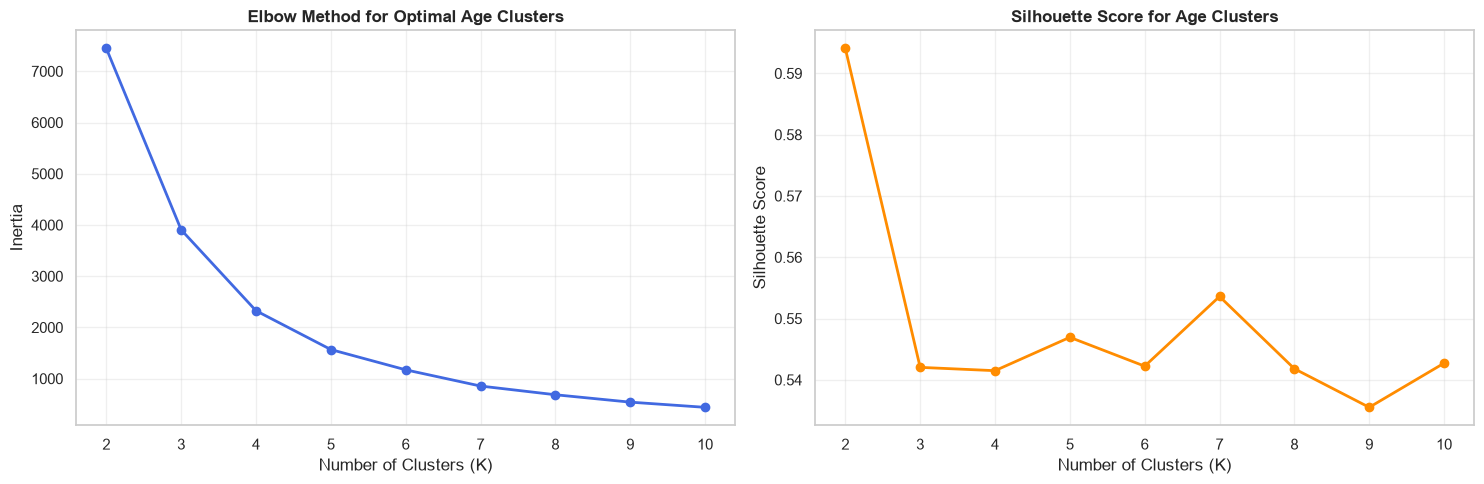

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

# Elbow Method
axes[0].plot(
    list(k_values),
    inertia_values,
    marker="o",
    color="royalblue",
    linewidth=2
)

axes[0].set_title(
    "Elbow Method for Optimal Age Clusters",
    fontweight="bold"
)

axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(k_values))
axes[0].grid(alpha=0.3)

# Silhouette Score
axes[1].plot(
    list(k_values),
    silhouette_values,
    marker="o",
    color="darkorange",
    linewidth=2
)

axes[1].set_title(
    "Silhouette Score for Age Clusters",
    fontweight="bold"
)

axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(k_values))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Comparison function

In [15]:
def summarize_age_clusters(
    scaled_age_data,
    original_data,
    k
):
    # K-Means model
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Cluster labels
    labels = model.fit_predict(scaled_age_data)

    # Temporary comparison data
    temp_df = original_data[["Age"]].copy()
    temp_df["Cluster"] = labels

    # Har cluster ki summary
    summary = (
        temp_df
        .groupby("Cluster")
        .agg(
            Minimum_Age=("Age", "min"),
            Maximum_Age=("Age", "max"),
            Average_Age=("Age", "mean"),
            Customer_Count=("Age", "size")
        )
        .sort_values("Average_Age")
        .reset_index(drop=True)
    )

    # Meaningful segment order
    summary.insert(
        0,
        "Segment",
        range(1, len(summary) + 1)
    )

    summary["Customer_Percentage"] = (
        summary["Customer_Count"]
        / len(original_data)
        * 100
    )

    summary.insert(0, "K", k)

    summary["Average_Age"] = (
        summary["Average_Age"].round(2)
    )

    summary["Customer_Percentage"] = (
        summary["Customer_Percentage"].round(2)
    )

    return summary

# Candidate cluster results

In [16]:
candidate_k_values = [2, 3, 4, 5, 7]

candidate_summaries = []

for k in candidate_k_values:

    result = summarize_age_clusters(
        scaled_age_data=X_age_scaled,
        original_data=df_clean,
        k=k
    )

    candidate_summaries.append(result)

candidate_comparison = pd.concat(
    candidate_summaries,
    ignore_index=True
)

display(candidate_comparison)

,K,Segment,Minimum_Age,Maximum_Age,Average_Age,Customer_Count,Customer_Percentage
0,2,1,18.0,45.0,35.11,14367,61.17
1,2,2,46.0,99.0,55.94,9119,38.83
2,3,1,18.0,37.0,31.12,8584,36.55
3,3,2,38.0,51.0,43.57,8967,38.18
4,3,3,52.0,99.0,60.11,5935,25.27
5,4,1,18.0,33.0,28.37,5263,22.41
6,4,2,34.0,44.0,38.65,8575,36.51
7,4,3,45.0,57.0,50.42,6272,26.71
8,4,4,58.0,99.0,64.48,3376,14.37
9,5,1,18.0,32.0,27.63,4538,19.32


# Final model train

In [17]:
# Selected optimal cluster count
optimal_k = 4

# Final K-Means model
final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Har customer ka raw cluster label
raw_cluster_labels = final_kmeans.fit_predict(
    X_age_scaled
)

print("Model successfully trained.")
print("Number of clusters:", optimal_k)

Model successfully trained.
Number of clusters: 4


# Clusters ko youngest-to-oldest order

In [18]:
# Scaled cluster centers ko original age mein convert karna
original_cluster_centers = (
    age_scaler
    .inverse_transform(
        final_kmeans.cluster_centers_
    )
    .flatten()
)

# Cluster IDs ko average age ke order mein sort karna
sorted_cluster_ids = np.argsort(
    original_cluster_centers
)

# Raw cluster ID ko ordered segment ID mein map karna
cluster_order_mapping = {
    raw_id: ordered_id + 1
    for ordered_id, raw_id
    in enumerate(sorted_cluster_ids)
}

# Ordered cluster ID dataset mein add karna
df_clean["Age_Cluster_ID"] = [
    cluster_order_mapping[label]
    for label in raw_cluster_labels
]

print("Original cluster centers:")
print(original_cluster_centers)

print("\nCluster order mapping:")
print(cluster_order_mapping)

Original cluster centers:
[28.36690101 50.41661352 38.64536443 64.47541469]

Cluster order mapping:
{np.int64(0): 1, np.int64(2): 2, np.int64(1): 3, np.int64(3): 4}


# Dynamic age ranges calculate

In [19]:
kmeans_age_summary = (
    df_clean
    .groupby("Age_Cluster_ID")
    .agg(
        Minimum_Age=("Age", "min"),
        Maximum_Age=("Age", "max"),
        Average_Age=("Age", "mean"),
        Customer_Count=("Age", "size")
    )
    .reset_index()
)

kmeans_age_summary["Customer_Percentage"] = (
    kmeans_age_summary["Customer_Count"]
    / len(df_clean)
    * 100
)

kmeans_age_summary["Average_Age"] = (
    kmeans_age_summary["Average_Age"].round(2)
)

kmeans_age_summary["Customer_Percentage"] = (
    kmeans_age_summary["Customer_Percentage"].round(2)
)

display(kmeans_age_summary)

,Age_Cluster_ID,Minimum_Age,Maximum_Age,Average_Age,Customer_Count,Customer_Percentage
0,1,18.0,33.0,28.37,5263,22.41
1,2,34.0,44.0,38.65,8575,36.51
2,3,45.0,57.0,50.42,6272,26.71
3,4,58.0,99.0,64.48,3376,14.37


# Readable age-group names create

In [20]:
# Cluster ID ke liye dynamic label mapping
age_group_mapping = {
    row["Age_Cluster_ID"]:
    (
        f'Segment {int(row["Age_Cluster_ID"])}: '
        f'{int(row["Minimum_Age"])}-'
        f'{int(row["Maximum_Age"])}'
    )
    for _, row in kmeans_age_summary.iterrows()
}

# New dynamic feature create karna
df_clean["Dynamic_Age_Group_KMeans"] = (
    df_clean["Age_Cluster_ID"]
    .map(age_group_mapping)
)

# Correct display order
ordered_age_groups = [
    age_group_mapping[cluster_id]
    for cluster_id
    in sorted(age_group_mapping)
]

df_clean["Dynamic_Age_Group_KMeans"] = pd.Categorical(
    df_clean["Dynamic_Age_Group_KMeans"],
    categories=ordered_age_groups,
    ordered=True
)

display(
    df_clean[
        [
            "Age",
            "Age_Cluster_ID",
            "Dynamic_Age_Group_KMeans"
        ]
    ].head(10)
)

,Age,Age_Cluster_ID,Dynamic_Age_Group_KMeans
0,33.0,1,Segment 1: 18-33
1,34.0,2,Segment 2: 34-44
2,60.0,4,Segment 4: 58-99
3,50.0,3,Segment 3: 45-57
4,47.0,3,Segment 3: 45-57
5,49.0,3,Segment 3: 45-57
6,39.0,2,Segment 2: 34-44
7,39.0,2,Segment 2: 34-44
8,24.0,1,Segment 1: 18-33
9,34.0,2,Segment 2: 34-44


# Feature validate

In [21]:
# Missing group assignments
print(
    "Missing Age Group Assignments:",
    df_clean[
        "Dynamic_Age_Group_KMeans"
    ].isna().sum()
)

# Age group distribution
display(
    df_clean[
        "Dynamic_Age_Group_KMeans"
    ].value_counts(sort=False).to_frame(
        "Customer_Count"
    )
)

Missing Age Group Assignments: 0


,Customer_Count
Dynamic_Age_Group_KMeans,
Segment 1: 18-33,5263
Segment 2: 34-44,8575
Segment 3: 45-57,6272
Segment 4: 58-99,3376


# Target distribution check

In [22]:
recommendation_distribution = (
    df_clean["Recommended IND"]
    .value_counts()
    .sort_index()
    .to_frame("Customer_Count")
)

recommendation_distribution["Percentage"] = (
    recommendation_distribution["Customer_Count"]
    / len(df_clean)
    * 100
).round(2)

display(recommendation_distribution)

,Customer_Count,Percentage
Recommended IND,,
0,4172,17.76
1,19314,82.24


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

# Features aur target prepare karo

In [24]:
# Input feature
X_tree = df_clean[["Age"]].copy()

# Behaviour target
y_tree = df_clean["Recommended IND"].copy()

print("Feature Shape:", X_tree.shape)
print("Target Shape:", y_tree.shape)

print(
    "Missing Values:",
    X_tree.isna().sum().sum()
)

Feature Shape: (23486, 1)
Target Shape: (23486,)
Missing Values: 0


In [25]:
# Stratified cross-validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

tree_results = []

for leaf_count in range(2, 9):

    tree_model = DecisionTreeClassifier(
        max_leaf_nodes=leaf_count,
        min_samples_leaf=0.05,
        random_state=42
    )

    auc_scores = cross_val_score(
        tree_model,
        X_tree,
        y_tree,
        cv=cv_strategy,
        scoring="roc_auc"
    )

    tree_results.append({
        "Leaf_Segments": leaf_count,
        "Mean_ROC_AUC": auc_scores.mean(),
        "AUC_Standard_Deviation": auc_scores.std(),
        "AUC_Standard_Error": (
            auc_scores.std() /
            np.sqrt(len(auc_scores))
        )
    })

tree_evaluation = pd.DataFrame(tree_results)

tree_evaluation[
    [
        "Mean_ROC_AUC",
        "AUC_Standard_Deviation",
        "AUC_Standard_Error"
    ]
] = tree_evaluation[
    [
        "Mean_ROC_AUC",
        "AUC_Standard_Deviation",
        "AUC_Standard_Error"
    ]
].round(4)

display(tree_evaluation)

,Leaf_Segments,Mean_ROC_AUC,AUC_Standard_Deviation,AUC_Standard_Error
0,2,0.5160,0.0068,0.0030
1,3,0.5193,0.0055,0.0025
2,4,0.5264,0.0044,0.0020
3,5,0.5330,0.0075,0.0034
4,6,0.5346,0.0070,0.0031
5,7,0.5359,0.0110,0.0049
6,8,0.5347,0.0102,0.0045


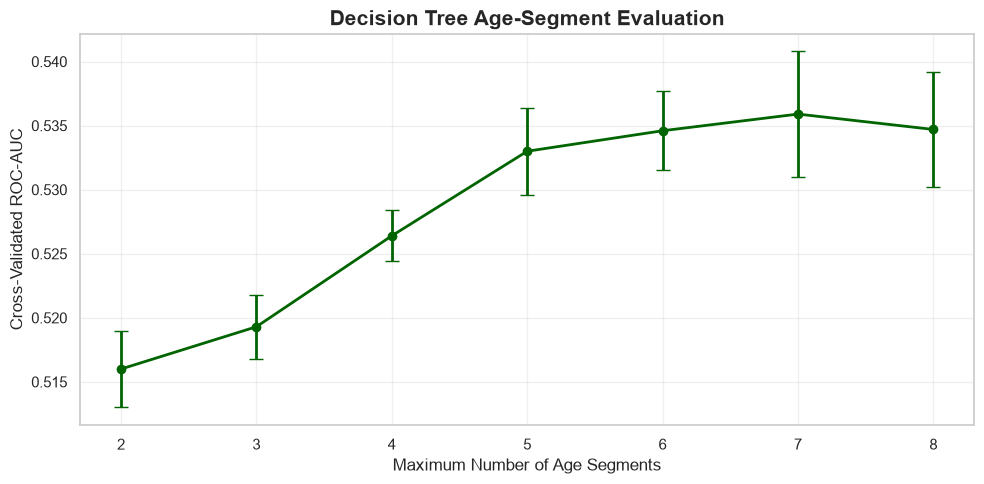

In [26]:
plt.figure(figsize=(10, 5))

plt.errorbar(
    tree_evaluation["Leaf_Segments"],
    tree_evaluation["Mean_ROC_AUC"],
    yerr=tree_evaluation["AUC_Standard_Error"],
    marker="o",
    capsize=5,
    linewidth=2,
    color="darkgreen"
)

plt.title(
    "Decision Tree Age-Segment Evaluation",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Maximum Number of Age Segments")
plt.ylabel("Cross-Validated ROC-AUC")
plt.xticks(tree_evaluation["Leaf_Segments"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Highest mean score wala result
best_result = tree_evaluation.loc[
    tree_evaluation["Mean_ROC_AUC"].idxmax()
]

# One-standard-error acceptance limit
auc_acceptance_limit = (
    best_result["Mean_ROC_AUC"]
    - best_result["AUC_Standard_Error"]
)

# Limit ke andar sabse simple tree
eligible_models = tree_evaluation[
    tree_evaluation["Mean_ROC_AUC"]
    >= auc_acceptance_limit
].sort_values("Leaf_Segments")

selected_tree_leaf_count = int(
    eligible_models.iloc[0]["Leaf_Segments"]
)

print(
    "Highest Mean ROC-AUC:",
    best_result["Mean_ROC_AUC"]
)

print(
    "One-SE Acceptance Limit:",
    round(auc_acceptance_limit, 4)
)

print(
    "Selected Decision Tree Segments:",
    selected_tree_leaf_count
)

Highest Mean ROC-AUC: 0.5359
One-SE Acceptance Limit: 0.531
Selected Decision Tree Segments: 5


# final Decision Tree train

In [28]:
from sklearn.tree import (
    DecisionTreeClassifier,
    export_text
)

# Final Decision Tree
final_age_tree = DecisionTreeClassifier(
    max_leaf_nodes=selected_tree_leaf_count,
    min_samples_leaf=0.05,
    random_state=42
)

# Complete dataset par model fit karna
final_age_tree.fit(
    X_tree,
    y_tree
)

print("Decision Tree successfully trained.")
print(
    "Selected maximum segments:",
    selected_tree_leaf_count
)

Decision Tree successfully trained.
Selected maximum segments: 5


In [29]:
# Internal nodes ki thresholds
tree_thresholds = final_age_tree.tree_.threshold

# -2 leaf nodes represent karta hai
age_cut_points = sorted([
    threshold
    for threshold in tree_thresholds
    if threshold != -2
])

print("Decision Tree Age Cut-Points:")

for threshold in age_cut_points:
    print(round(threshold, 2))

Decision Tree Age Cut-Points:
25.5
38.5
39.5
53.5


In [30]:
tree_rules = export_text(
    final_age_tree,
    feature_names=["Age"]
)

print(tree_rules)

|--- Age <= 53.50
|   |--- Age <= 25.50
|   |   |--- class: 1
|   |--- Age >  25.50
|   |   |--- Age <= 38.50
|   |   |   |--- class: 1
|   |   |--- Age >  38.50
|   |   |   |--- Age <= 39.50
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  39.50
|   |   |   |   |--- class: 1
|--- Age >  53.50
|   |--- class: 1



In [31]:
# Har customer kis final leaf mein gaya
df_clean["Tree_Leaf_Node"] = (
    final_age_tree.apply(X_tree)
)

print(
    "Unique Tree Leaves:",
    df_clean["Tree_Leaf_Node"].nunique()
)

Unique Tree Leaves: 5


In [32]:
# Leaf nodes ko minimum age ke order mein arrange karna
leaf_order = (
    df_clean
    .groupby("Tree_Leaf_Node")["Age"]
    .min()
    .sort_values()
    .index
    .tolist()
)

# Raw leaf node ko ordered segment ID dena
tree_segment_mapping = {
    leaf_node: segment_number + 1
    for segment_number, leaf_node
    in enumerate(leaf_order)
}

df_clean["Tree_Age_Segment_ID"] = (
    df_clean["Tree_Leaf_Node"]
    .map(tree_segment_mapping)
)

In [33]:
tree_age_summary = (
    df_clean
    .groupby("Tree_Age_Segment_ID")
    .agg(
        Minimum_Age=("Age", "min"),
        Maximum_Age=("Age", "max"),
        Average_Age=("Age", "mean"),
        Customer_Count=("Age", "size"),
        Recommendation_Rate=(
            "Recommended IND",
            "mean"
        ),
        Average_Rating=("Rating", "mean"),
        Average_Feedback=(
            "Positive Feedback Count",
            "mean"
        )
    )
    .reset_index()
)

tree_age_summary["Customer_Percentage"] = (
    tree_age_summary["Customer_Count"]
    / len(df_clean)
    * 100
)

tree_age_summary["Recommendation_Rate"] *= 100

round_columns = [
    "Average_Age",
    "Recommendation_Rate",
    "Average_Rating",
    "Average_Feedback",
    "Customer_Percentage"
]

tree_age_summary[round_columns] = (
    tree_age_summary[round_columns].round(2)
)

display(tree_age_summary)

,Tree_Age_Segment_ID,Minimum_Age,Maximum_Age,Average_Age,Customer_Count,Recommendation_Rate,Average_Rating,Average_Feedback,Customer_Percentage
0,1,18.0,25.0,23.04,1223,85.12,4.29,2.09,5.21
1,2,26.0,38.0,32.99,8141,80.00,4.14,2.33,34.66
2,3,39.0,39.0,39.00,1269,87.31,4.30,2.86,5.40
3,4,40.0,53.0,45.99,7920,81.55,4.17,2.51,33.72
4,5,54.0,99.0,61.65,4933,85.00,4.28,2.94,21.00


In [34]:
tree_group_labels = {
    row["Tree_Age_Segment_ID"]:
    (
        f'Tree Segment '
        f'{int(row["Tree_Age_Segment_ID"])}: '
        f'{int(row["Minimum_Age"])}-'
        f'{int(row["Maximum_Age"])}'
    )
    for _, row in tree_age_summary.iterrows()
}

df_clean["Dynamic_Age_Group_Tree"] = (
    df_clean["Tree_Age_Segment_ID"]
    .map(tree_group_labels)
)

ordered_tree_groups = [
    tree_group_labels[segment_id]
    for segment_id in sorted(tree_group_labels)
]

df_clean["Dynamic_Age_Group_Tree"] = pd.Categorical(
    df_clean["Dynamic_Age_Group_Tree"],
    categories=ordered_tree_groups,
    ordered=True
)

display(
    df_clean[
        [
            "Age",
            "Recommended IND",
            "Tree_Age_Segment_ID",
            "Dynamic_Age_Group_Tree"
        ]
    ].head(10)
)

,Age,Recommended IND,Tree_Age_Segment_ID,Dynamic_Age_Group_Tree
0,33.0,1,2,Tree Segment 2: 26-38
1,34.0,1,2,Tree Segment 2: 26-38
2,60.0,0,5,Tree Segment 5: 54-99
3,50.0,1,4,Tree Segment 4: 40-53
4,47.0,1,4,Tree Segment 4: 40-53
5,49.0,0,4,Tree Segment 4: 40-53
6,39.0,1,3,Tree Segment 3: 39-39
7,39.0,1,3,Tree Segment 3: 39-39
8,24.0,1,1,Tree Segment 1: 18-25
9,34.0,1,2,Tree Segment 2: 26-38


In [35]:
print(
    "Missing Tree Group Assignments:",
    df_clean[
        "Dynamic_Age_Group_Tree"
    ].isna().sum()
)

display(
    df_clean[
        "Dynamic_Age_Group_Tree"
    ].value_counts(sort=False).to_frame(
        "Customer_Count"
    )
)

Missing Tree Group Assignments: 0


,Customer_Count
Dynamic_Age_Group_Tree,
Tree Segment 1: 18-25,1223
Tree Segment 2: 26-38,8141
Tree Segment 3: 39-39,1269
Tree Segment 4: 40-53,7920
Tree Segment 5: 54-99,4933


In [36]:
# Selected Decision Tree ka CV score
selected_tree_auc = tree_evaluation.loc[
    tree_evaluation["Leaf_Segments"]
    == selected_tree_leaf_count,
    "Mean_ROC_AUC"
].iloc[0]

# Smallest K-Means segment percentage
smallest_kmeans_segment = (
    kmeans_age_summary[
        "Customer_Percentage"
    ].min()
)

# Smallest Decision Tree segment percentage
smallest_tree_segment = (
    tree_age_summary[
        "Customer_Percentage"
    ].min()
)

method_comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "Decision Tree"
    ],
    "Selected_Segments": [
        optimal_k,
        selected_tree_leaf_count
    ],
    "Evaluation_Metric": [
        "Silhouette Score",
        "Cross-Validated ROC-AUC"
    ],
    "Metric_Value": [
        0.5415,
        selected_tree_auc
    ],
    "Smallest_Segment_Percentage": [
        smallest_kmeans_segment,
        smallest_tree_segment
    ],
    "Segmentation_Basis": [
        "Natural Age Distribution",
        "Recommendation Behaviour"
    ]
})

method_comparison[
    [
        "Metric_Value",
        "Smallest_Segment_Percentage"
    ]
] = method_comparison[
    [
        "Metric_Value",
        "Smallest_Segment_Percentage"
    ]
].round(4)

display(method_comparison)

,Method,Selected_Segments,Evaluation_Metric,Metric_Value,Smallest_Segment_Percentage,Segmentation_Basis
0,K-Means,4,Silhouette Score,0.5415,14.37,Natural Age Distribution
1,Decision Tree,5,Cross-Validated ROC-AUC,0.5330,5.21,Recommendation Behaviour


In [37]:
kmeans_behaviour_summary = (
    df_clean
    .groupby(
        "Dynamic_Age_Group_KMeans",
        observed=False
    )
    .agg(
        Customer_Count=("Age", "size"),
        Average_Age=("Age", "mean"),
        Average_Rating=("Rating", "mean"),
        Recommendation_Rate=(
            "Recommended IND",
            "mean"
        ),
        Average_Positive_Feedback=(
            "Positive Feedback Count",
            "mean"
        )
    )
    .reset_index()
)

kmeans_behaviour_summary[
    "Customer_Percentage"
] = (
    kmeans_behaviour_summary["Customer_Count"]
    / len(df_clean)
    * 100
)

kmeans_behaviour_summary[
    "Recommendation_Rate"
] *= 100

numeric_columns = [
    "Average_Age",
    "Average_Rating",
    "Recommendation_Rate",
    "Average_Positive_Feedback",
    "Customer_Percentage"
]

kmeans_behaviour_summary[numeric_columns] = (
    kmeans_behaviour_summary[numeric_columns]
    .round(2)
)

display(kmeans_behaviour_summary)

,Dynamic_Age_Group_KMeans,Customer_Count,Average_Age,Average_Rating,Recommendation_Rate,Average_Positive_Feedback,Customer_Percentage
0,Segment 1: 18-33,5263,28.37,4.18,80.83,2.02,22.41
1,Segment 2: 34-44,8575,38.65,4.18,81.76,2.63,36.51
2,Segment 3: 45-57,6272,50.42,4.19,82.35,2.63,26.71
3,Segment 4: 58-99,3376,64.48,4.30,85.43,2.92,14.37


In [38]:
# K-Means feature ko final feature banana
df_clean["Dynamic_Age_Group"] = (
    df_clean[
        "Dynamic_Age_Group_KMeans"
    ].copy()
)

# Final feature validation
print(
    "Final Feature Missing Values:",
    df_clean[
        "Dynamic_Age_Group"
    ].isna().sum()
)

display(
    df_clean[
        [
            "Age",
            "Dynamic_Age_Group",
            "Rating",
            "Recommended IND",
            "Positive Feedback Count"
        ]
    ].head(10)
)

Final Feature Missing Values: 0


,Age,Dynamic_Age_Group,Rating,Recommended IND,Positive Feedback Count
0,33.0,Segment 1: 18-33,4,1,0
1,34.0,Segment 2: 34-44,5,1,4
2,60.0,Segment 4: 58-99,3,0,0
3,50.0,Segment 3: 45-57,5,1,0
4,47.0,Segment 3: 45-57,5,1,6
5,49.0,Segment 3: 45-57,2,0,4
6,39.0,Segment 2: 34-44,5,1,1
7,39.0,Segment 2: 34-44,4,1,4
8,24.0,Segment 1: 18-33,5,1,0
9,34.0,Segment 2: 34-44,5,1,0


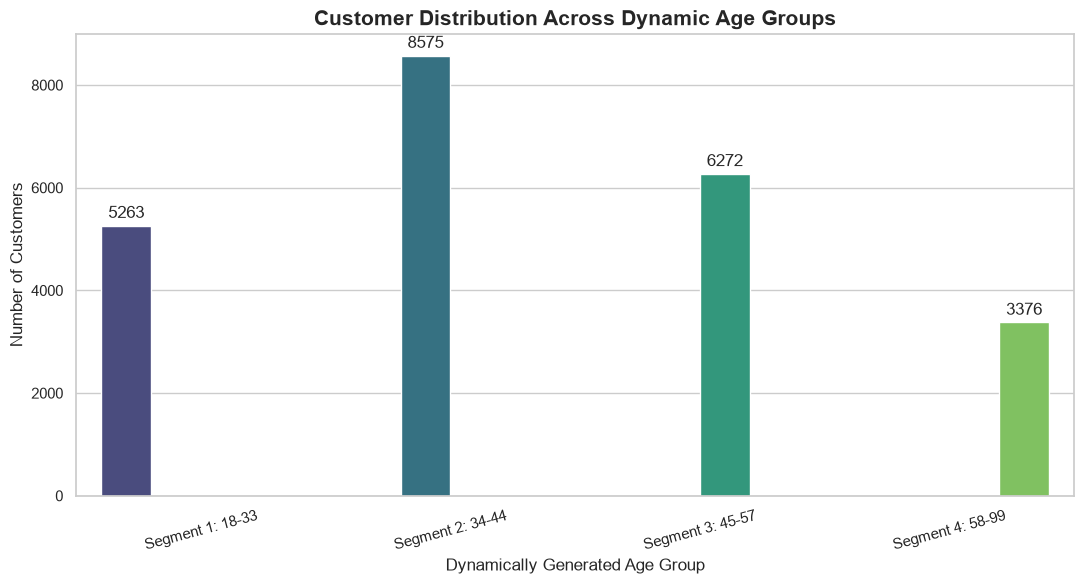

In [39]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=kmeans_behaviour_summary,
    x="Dynamic_Age_Group_KMeans",
    y="Customer_Count",
    hue="Dynamic_Age_Group_KMeans",
    palette="viridis",
    legend=False
)

# Bar ke upar values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.title(
    "Customer Distribution Across Dynamic Age Groups",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Dynamically Generated Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

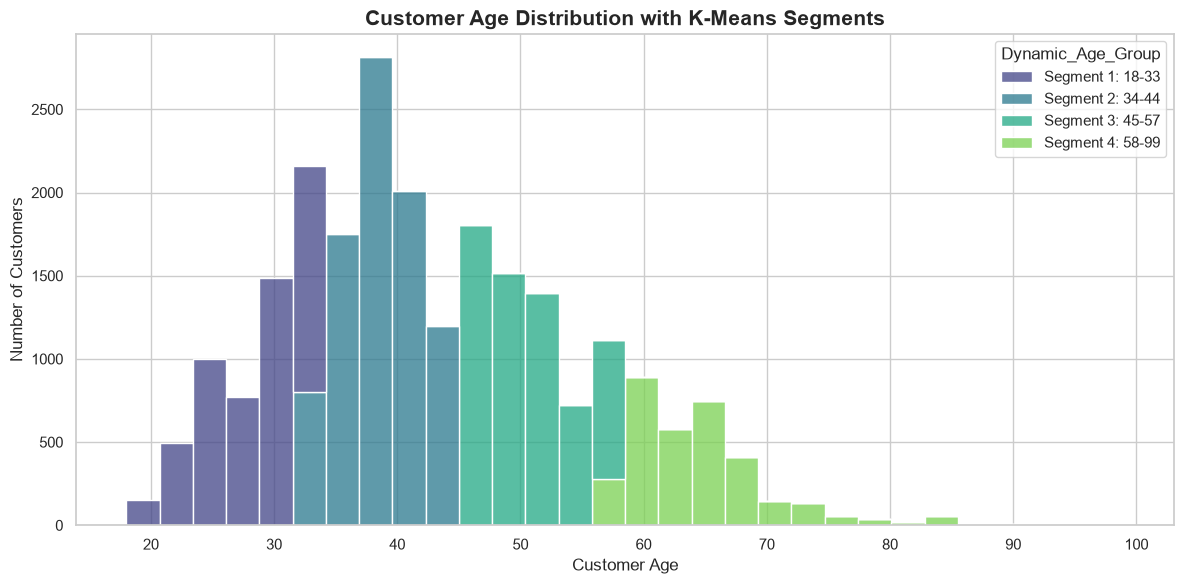

In [40]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_clean,
    x="Age",
    hue="Dynamic_Age_Group",
    bins=30,
    multiple="stack",
    palette="viridis",
    edgecolor="white"
)

plt.title(
    "Customer Age Distribution with K-Means Segments",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

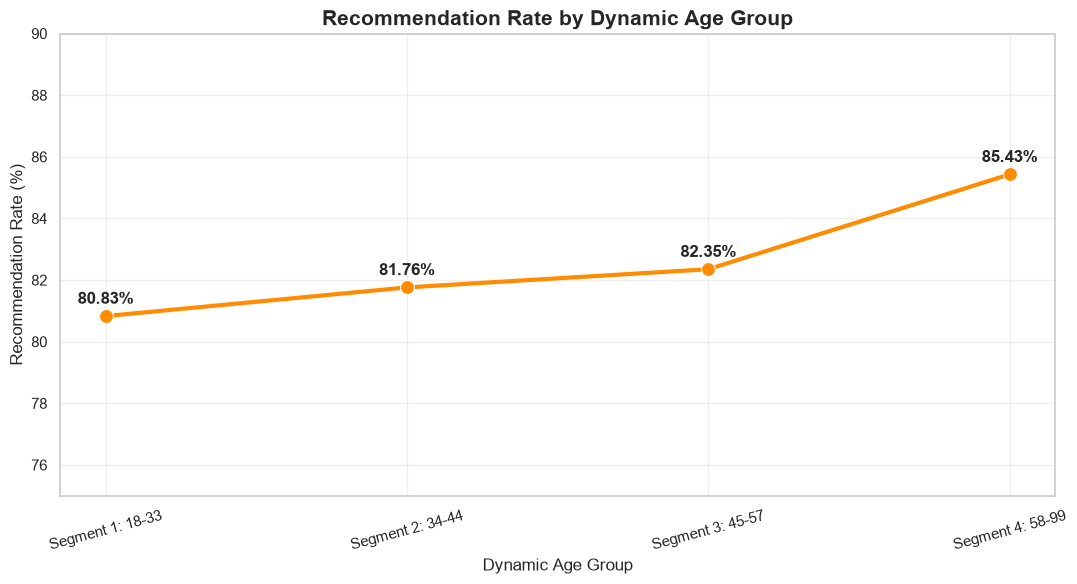

In [41]:
plt.figure(figsize=(11, 6))

ax = sns.lineplot(
    data=kmeans_behaviour_summary,
    x="Dynamic_Age_Group_KMeans",
    y="Recommendation_Rate",
    marker="o",
    markersize=10,
    linewidth=3,
    color="darkorange"
)

# Har point par percentage label
for index, row in kmeans_behaviour_summary.iterrows():

    ax.text(
        index,
        row["Recommendation_Rate"] + 0.4,
        f'{row["Recommendation_Rate"]:.2f}%',
        ha="center",
        fontweight="bold"
    )

plt.title(
    "Recommendation Rate by Dynamic Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Dynamic Age Group")
plt.ylabel("Recommendation Rate (%)")
plt.ylim(75, 90)
plt.xticks(rotation=15)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

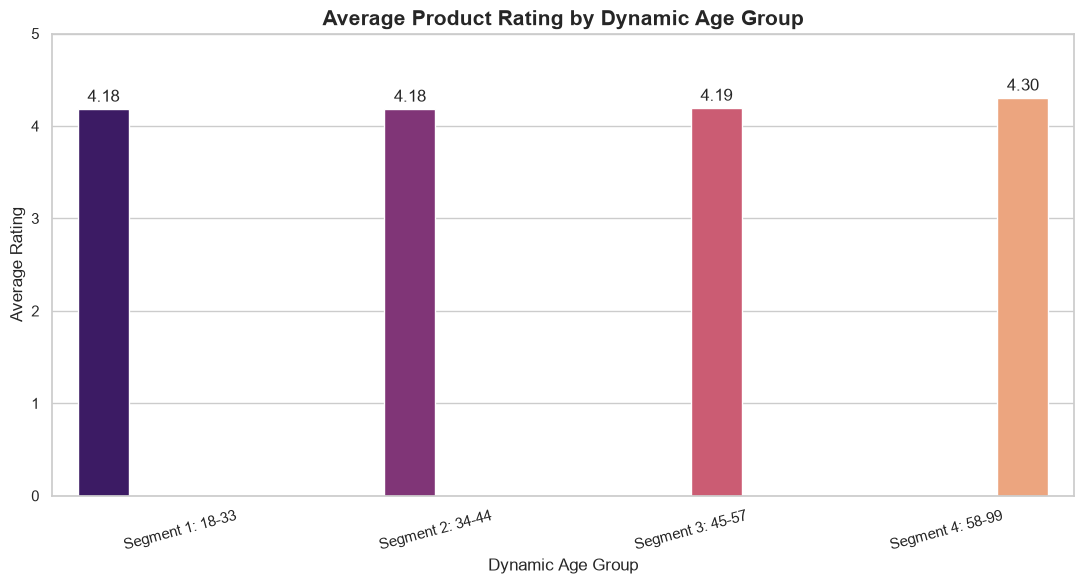

In [42]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=kmeans_behaviour_summary,
    x="Dynamic_Age_Group_KMeans",
    y="Average_Rating",
    hue="Dynamic_Age_Group_KMeans",
    palette="magma",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.title(
    "Average Product Rating by Dynamic Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Dynamic Age Group")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [43]:
# Complete working dataset ki copy
final_df = df_clean.copy()

# Temporary/model comparison columns
technical_columns = [
    "Age_Cluster_ID",
    "Tree_Leaf_Node",
    "Tree_Age_Segment_ID",
    "Dynamic_Age_Group_KMeans",
    "Dynamic_Age_Group_Tree"
]

# Sirf temporary columns remove karna
final_df = final_df.drop(
    columns=technical_columns,
    errors="ignore"
)

print("Final Dataset Shape:", final_df.shape)
print("\nFinal Columns:")
print(final_df.columns.tolist())

Final Dataset Shape: (23486, 12)

Final Columns:
['number', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name', 'Dynamic_Age_Group']


In [44]:
print(
    "Missing Dynamic Age Groups:",
    final_df[
        "Dynamic_Age_Group"
    ].isna().sum()
)

print(
    "Unique Dynamic Age Groups:",
    final_df[
        "Dynamic_Age_Group"
    ].nunique()
)

display(
    final_df[
        [
            "Age",
            "Dynamic_Age_Group",
            "Rating",
            "Recommended IND",
            "Positive Feedback Count"
        ]
    ].head(10)
)

Missing Dynamic Age Groups: 0
Unique Dynamic Age Groups: 4


,Age,Dynamic_Age_Group,Rating,Recommended IND,Positive Feedback Count
0,33.0,Segment 1: 18-33,4,1,0
1,34.0,Segment 2: 34-44,5,1,4
2,60.0,Segment 4: 58-99,3,0,0
3,50.0,Segment 3: 45-57,5,1,0
4,47.0,Segment 3: 45-57,5,1,6
5,49.0,Segment 3: 45-57,2,0,4
6,39.0,Segment 2: 34-44,5,1,1
7,39.0,Segment 2: 34-44,4,1,4
8,24.0,Segment 1: 18-33,5,1,0
9,34.0,Segment 2: 34-44,5,1,0


In [45]:
final_df.to_csv(
    "womens_clothing_dynamic_age_groups.csv",
    index=False
)

print(
    "Final processed dataset successfully saved."
)

Final processed dataset successfully saved.


In [46]:
# Final K-Means segment analysis
kmeans_behaviour_summary.to_csv(
    "dynamic_age_group_summary.csv",
    index=False
)

# K-Means versus Decision Tree comparison
method_comparison.to_csv(
    "age_segmentation_method_comparison.csv",
    index=False
)

# Decision Tree segment analysis
tree_age_summary.to_csv(
    "decision_tree_age_group_summary.csv",
    index=False
)

print("All analysis summaries successfully saved.")

All analysis summaries successfully saved.


In [47]:
# Exported dataset dobara read karna
verification_df = pd.read_csv(
    "womens_clothing_dynamic_age_groups.csv"
)

print(
    "Exported Dataset Shape:",
    verification_df.shape
)

print(
    "Dynamic Feature Available:",
    "Dynamic_Age_Group"
    in verification_df.columns
)

print(
    "Missing Dynamic Groups:",
    verification_df[
        "Dynamic_Age_Group"
    ].isna().sum()
)

display(verification_df.head())

Exported Dataset Shape: (23486, 12)
Dynamic Feature Available: True
Missing Dynamic Groups: 0


,number,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Dynamic_Age_Group
0,0,767,33.0,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Segment 1: 18-33
1,1,1080,34.0,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Segment 2: 34-44
2,2,1077,60.0,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Segment 4: 58-99
3,3,1049,50.0,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,Segment 3: 45-57
4,4,847,47.0,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Segment 3: 45-57
